In [ ]:
from pathlib import Path
import sys
import importlib
import os

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
from IPython.display import display

# Notebook location expected:
NB_DIR = Path.cwd()
OCGM_DIR = NB_DIR.parent
PROJECT_DIR = OCGM_DIR.parent

for path in [PROJECT_DIR, OCGM_DIR / "scripts"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import theme.plot_theme as ptheme
import ocean_analysis as oa

# Reload during notebook development
importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(oa)


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


<module 'ocean_analysis_adjusted' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis_adjusted.py'>

Red box lat range: 22.14 to 23.86
Red box lon range: -140.94 to -139.06
Vortex box saving is DEACTIVATED.


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\

(<Figure size 1200x600 with 2 Axes>,
 <GeoAxes: title={'center': 'GPGP Vortex Detection January 2020'}>)

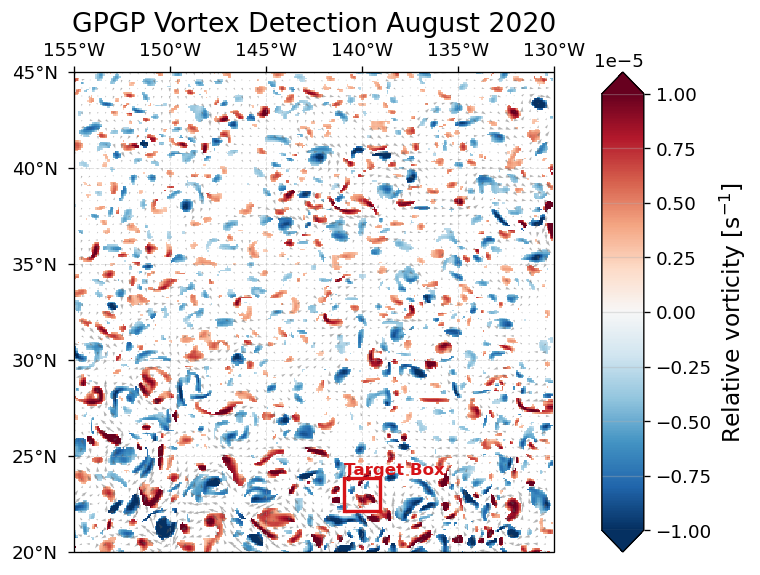

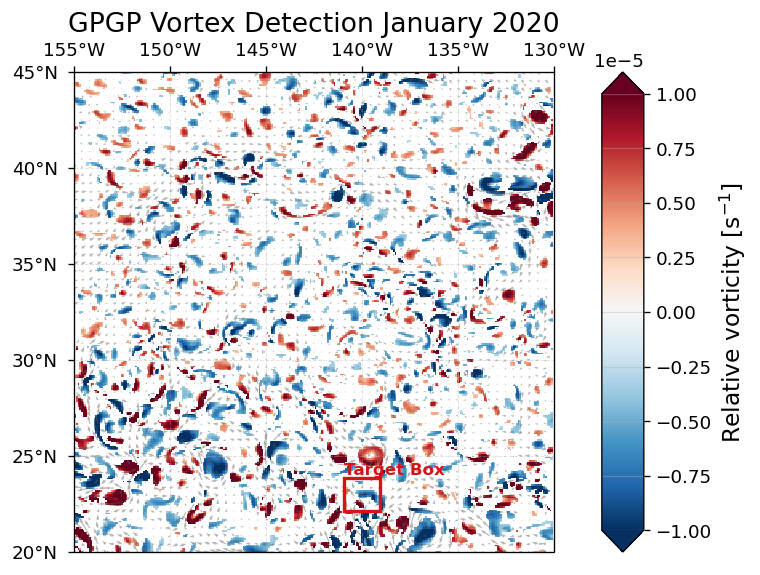

In [5]:
# Fixed symmetric colorbar magnitude
VORT_ABS_MAX = 1.6e-5

# Fixed target plotting domain
MAP_EXTENT = [-155, -130, 20, 45]

# 1. Load Data

surface_ds_2020 = oa.process_glorys_data('../data/input/GPGP_aug2020.nc', averaging_period='1D')
surface_ds_2021 = oa.process_glorys_data('../data/input/GPGP_aug2021.nc', averaging_period='1D')
surface_ds_2022 = oa.process_glorys_data('../data/input/GPGP_aug2022.nc', averaging_period='1D')
surface_ds_2023 = oa.process_glorys_data('../data/input/GPGP_aug2023.nc', averaging_period='1D')
surface_ds_2020_winter = oa.process_glorys_data('../data/input/GPGP_jan2020.nc', averaging_period='1D')
surface_ds_2021_winter = oa.process_glorys_data('../data/input/GPGP_jan2021.nc', averaging_period='1D')
surface_ds_2022_winter = oa.process_glorys_data('../data/input/GPGP_jan2022.nc', averaging_period='1D')
surface_ds_2023_winter = oa.process_glorys_data('../data/input/GPGP_jan2023.nc', averaging_period='1D')


# 2. Compute Metrics

results_2020 = oa.calculate_okubo_weiss(surface_ds_2020)
signed_vort_2020, mask_2020 = oa.get_eddy_intensity(results_2020, alpha=0.2)
results_2020_winter = oa.calculate_okubo_weiss(surface_ds_2020_winter)
signed_vort_2020_winter, mask_2020_winter = oa.get_eddy_intensity(results_2020_winter, alpha=0.2)

    
# 3. SELECT TARGET DOMAIN
# lat_s, lat_n = 25.0, 27.0
# lon_w, lon_e = -145.0, -143.0
# lat_s, lat_n = 22.5, 27.5
# lon_w, lon_e = -145.0, -140.0
# lat_s, lat_n = 20.0, 45.0 # whole GPGP
# lon_w, lon_e = -155.0, -130.0 # whole GPGP
# lat_s, lat_n = 22.5, 27.5
# lon_w, lon_e = -145.0, -140.0
center_lat = 23.0
center_lon = -140.0

dlat = 192 / 111.32          # ≈ 1.725 deg
dlon = 192 / (111.32 * np.cos(np.deg2rad(center_lat)))   # ≈ 1.903 deg

lat_s = center_lat - dlat/2
lat_n = center_lat + dlat/2
lon_w = center_lon - dlon/2
lon_e = center_lon + dlon/2

print(f"Red box lat range: {lat_s:.2f} to {lat_n:.2f}")
print(f"Red box lon range: {lon_w:.2f} to {lon_e:.2f}")


les_box = oa.get_subdomain(lat_min=lat_s, lon_min=lon_w, lat_max=lat_n, lon_max=lon_e)

# Preprocess for Vortex Fitting

oa.preprocess_netcdf(surface_ds_2020, les_box, base_name='GPGP_aug2020', active=False, subtract_mean=True) 

# 4. Visualize with the Red Rectangle
oa.plot_eddy_intensity(signed_vort_2020, u=surface_ds_2020.uo, v=surface_ds_2020.vo, 
                       title="GPGP Vortex Detection August 2020",
                       target_box=les_box)

oa.plot_eddy_intensity(signed_vort_2020_winter, u=surface_ds_2020_winter.uo, v=surface_ds_2020_winter.vo, 
                       title="GPGP Vortex Detection January 2020",
                       target_box=les_box)


# # 5. Extract statistics strictly inside that box
# box_data = signed_vort.sel(longitude=slice(les_box[0], les_box[1]), 
#                            latitude=slice(les_box[2], les_box[3]))

# print(f"Stats for red box:")
# print(f"Number of eddy core pixels: {int(box_data.notnull().sum())}")

Number of daily frames: 366
First day: 2020-01-01
Last day : 2020-12-31
Shared vortex-core colorbar range: ±1.70e-05 s^-1


interactive(children=(IntSlider(value=0, description='Day index', max=365), Output()), _dom_classes=('widget-i…

c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\

KeyboardInterrupt: 

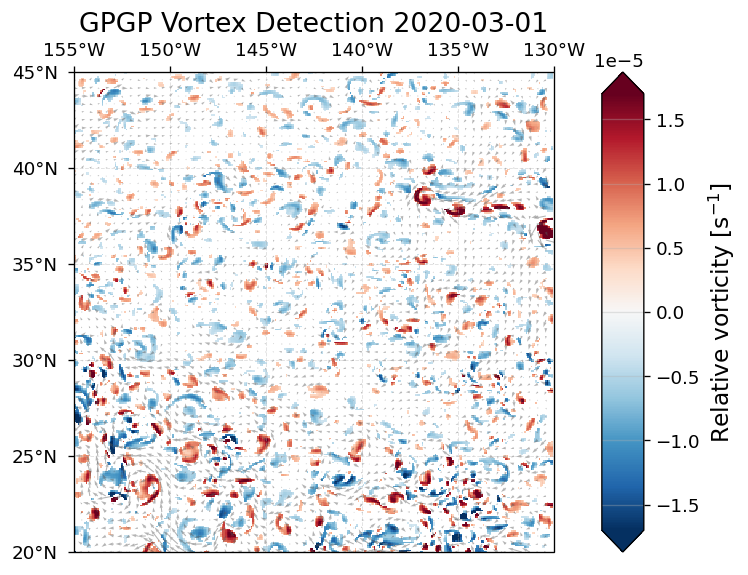

In [6]:
# ============================================================
# SETTINGS
# ============================================================

INPUT_FILE = "../data/input/GPGP_2020.nc"

START_DATE = "2020-01-01"
END_DATE = "2020-12-31"

frames_dir = (
    rf"C:\Users\Jelle Gortemaker\Downloads\gif_frames_"
    rf"{START_DATE}_to_{END_DATE}"
)
os.makedirs(frames_dir, exist_ok=True)

MAP_EXTENT = [-155, -130, 20, 45]

# Colorbar setting
# Option 1: fixed manual value
# VORT_ABS_MAX = 8e-6

# Option 2: automatically determine fixed range from detected vortex-core values
VORT_PERCENTILE = 98


# ============================================================
# DAILY TIME RANGES
# ============================================================

dates = pd.date_range(start=START_DATE, end=END_DATE, freq="D")

time_ranges = [
    (date.strftime("%Y-%m-%d"), date.strftime("%Y-%m-%d"))
    for date in dates
]

print(f"Number of daily frames: {len(time_ranges)}")
print(f"First day: {time_ranges[0][0]}")
print(f"Last day : {time_ranges[-1][0]}")


# ============================================================
# LOAD DAILY DATA
# ============================================================

surface_datasets = []
ow_results = []
signed_vort_list = []
mask_list = []

for tr in time_ranges:
    surface_ds = oa.process_glorys_data(
        INPUT_FILE,
        averaging_period="1D",
        time_range=tr,
    )

    results = oa.calculate_okubo_weiss(surface_ds)
    signed_vort, mask = oa.get_eddy_intensity(results, alpha=0.2)

    surface_datasets.append(surface_ds)
    ow_results.append(results)
    signed_vort_list.append(signed_vort)
    mask_list.append(mask)


# ============================================================
# SHARED COLORBAR RANGE BASED ON DETECTED VORTEX CORES
# ============================================================

vortex_values = np.concatenate([
    np.ravel(da.values[np.isfinite(da.values)])
    for da in signed_vort_list
])

if vortex_values.size == 0:
    raise ValueError("No detected vortex-core values found. Check the OW threshold or input data.")

VORT_ABS_MAX = np.nanpercentile(np.abs(vortex_values), VORT_PERCENTILE)
VORT_ABS_MAX = np.ceil(VORT_ABS_MAX / 1e-6) * 1e-6

print(f"Shared vortex-core colorbar range: ±{VORT_ABS_MAX:.2e} s^-1")


# ============================================================
# INTERACTIVE VIEWER
# ============================================================

def show_frame(i):
    fig, ax = oa.plot_eddy_intensity(
        signed_vort_list[i],
        u=surface_datasets[i].uo,
        v=surface_datasets[i].vo,
        title=f"GPGP Vortex Detection {time_ranges[i][0]}",
        extent=MAP_EXTENT,
        vabs=VORT_ABS_MAX,
    )
    plt.show()


widgets.interact(
    show_frame,
    i=widgets.IntSlider(
        min=0,
        max=len(time_ranges) - 1,
        step=1,
        value=0,
        description="Day index",
    ),
)


# ============================================================
# SAVE FRAMES FOR GIF
# ============================================================

for i, tr in enumerate(time_ranges):
    fig, ax = oa.plot_eddy_intensity(
        signed_vort_list[i],
        u=surface_datasets[i].uo,
        v=surface_datasets[i].vo,
        title=f"GPGP Vortex Detection {tr[0]}",
        extent=MAP_EXTENT,
        vabs=VORT_ABS_MAX,
    )

    frame_path = os.path.join(frames_dir, f"frame_{i:02d}_{tr[0]}.png")

    fig.savefig(
        frame_path,
        dpi=150,
        facecolor="white",
        bbox_inches="tight",
    )
    plt.close(fig)

print(f"Frames saved in: {frames_dir}")